In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.ticker as mtick

sys.path.append(os.path.abspath('../src'))

from data_loader import download_price_data, clean_price_data
from factors import compute_momentum, compute_volatility, compute_cross_sectional_zscore
from signals import build_composite_signal
from backtest import generate_target_weights

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


In [9]:
# 1. Load Data
mvp_universe = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
    'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
    'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM'
]
prices_raw, _ = download_price_data(mvp_universe, '2018-01-01', '2026-12-31')
prices = clean_price_data(prices_raw)
returns = prices.pct_change(fill_method=None).dropna()

# 2. Compute Raw Factors
raw_momentum = compute_momentum(prices).dropna(how='all')
raw_volatility = compute_volatility(returns).dropna(how='all')

# 3. Z-Score Factors
z_momentum = compute_cross_sectional_zscore(raw_momentum)
z_low_vol = -compute_cross_sectional_zscore(raw_volatility) # Inverted!

2026-03-27 12:29:09,723 - INFO - Downloading data for 30 tickers from 2018-01-01 to 2026-12-31...


2026-03-27 12:29:11,731 - INFO - Shape before cleaning: (2069, 30)
2026-03-27 12:29:11,737 - INFO - Shape after cleaning: (2069, 30) (0 dropped)
2026-03-27 12:29:11,740 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 12:29:11,742 - INFO - Computing annualized rolling volatility (window=252)...
2026-03-27 12:29:11,750 - INFO - Computing cross-sectional z-scores...
2026-03-27 12:29:11,752 - INFO - Computing cross-sectional z-scores...


In [10]:
# Combine factors into the Alpha Score
composite_scores = build_composite_signal(z_momentum, z_low_vol)

# Generate monthly target weights (Top 10 equal-weight portfolio)
target_weights = generate_target_weights(composite_scores, top_n=10)

print(f"Target Weights Shape: {target_weights.shape} (Months x Stocks)")
display(target_weights.tail(3))

2026-03-27 12:29:11,763 - INFO - Building composite signal (Momentum: 60%, Low-Vol: 40%)...
2026-03-27 12:29:11,766 - INFO - Generating monthly target weights for top 10 stocks...


Target Weights Shape: (87, 30) (Months x Stocks)


/Users/lorenzocc/Desktop/8. Programming/ServiceFabric/portport/src/backtest.py:16: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_scores = composite_scores.resample('BM').last()


Ticker,PFE,ABT,PG,KO,CRM,MCD,MA,MSFT,COST,V,...,NVDA,TSLA,AMZN,GOOGL,JNJ,ABBV,BRK-B,BAC,XOM,CVX
2026-01-30,0.0,0.0,0.0,0.1,0.0,0.1,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.1,0.1,0.1,0.0,0.1,0.0,0.0
2026-02-27,0.0,0.0,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.0,...,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.1,0.1,0.0
2026-03-31,0.0,0.0,0.0,0.1,0.0,0.1,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.1,0.0


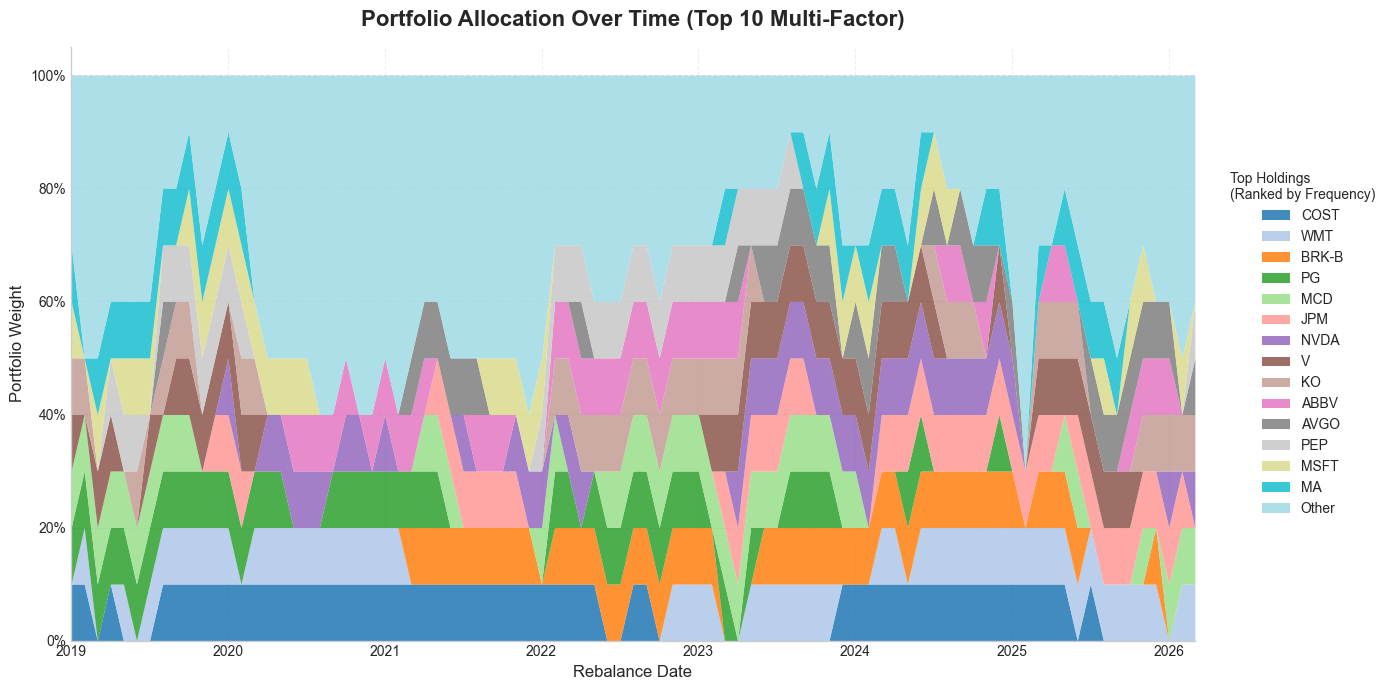

In [11]:
import matplotlib.ticker as mtick

# 1. Sort stocks by their average weight over the backtest.
# This anchors your highest-conviction/most-frequent names to the bottom of the chart.
sorted_columns = target_weights.mean().sort_values(ascending=False).index
plot_data = target_weights[sorted_columns]

# 2. Group the "long tail" into an 'Other' category.
# This prevents colormap exhaustion so every color in the legend is unique.
MAX_LEGEND_ITEMS = 15 
if len(plot_data.columns) > MAX_LEGEND_ITEMS:
    top_cols = plot_data.columns[:MAX_LEGEND_ITEMS-1]
    other_cols = plot_data.columns[MAX_LEGEND_ITEMS-1:]
    
    plot_data_clean = plot_data[top_cols].copy()
    plot_data_clean['Other'] = plot_data[other_cols].sum(axis=1)
else:
    plot_data_clean = plot_data.copy()

# 3. Plotting
fig, ax = plt.subplots(figsize=(14, 7))

# linewidth=0 removes the messy criss-cross lines
plot_data_clean.plot.area(
    ax=ax, 
    colormap='tab20', 
    alpha=0.85, 
    linewidth=0 
)

# Styling
ax.set_title('Portfolio Allocation Over Time (Top 10 Multi-Factor)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Portfolio Weight', fontsize=12)
ax.set_xlabel('Rebalance Date', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Clean up axes and grid
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Format legend cleanly outside the plot
ax.legend(
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5), 
    title="Top Holdings\n(Ranked by Frequency)", 
    frameon=False
)

plt.tight_layout()
plt.show()